# Example: Dynamical decoupling

There is a standard compilation stage for automatically applying dynamical decoupling (DD) sequences to an instruction schedule,
controlled by the `dd_mode` compiler option. By default the DD stage is disabled.

The `iqm.cpc.compiler.dd` module contains various utility functions the DD stage uses, e.g. for locating specific instructions in a schedule, constructing DD sequences, and replacing select instructions with them. For example, we can find locations of `Wait` instructions on qubit drive channels with a certain minimum duration, and replace them with an arbitrary sequence of `Wait` and `IQPulse` instructions that dynamically decouples the qubit, given that the total duration of the sequence is the same as the duration of the original `Wait`.

In [1]:
from IPython.core.display import HTML
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit.result import marginal_distribution

from iqm.station_control.interface.models import  MoveGateFrameTrackingMode

from iqm.pulla.pulla import Pulla
from iqm.pulla.utils_qiskit import qiskit_to_pulla, sweep_job_to_qiskit
from iqm.pulse.playlist.visualisation.base import inspect_playlist
from iqm.iqm_client.util import print_env_vars
from iqm.qiskit_iqm import IQMProvider

In [ ]:
print_env_vars()

provider = IQMProvider()
backend = provider.get_backend()
p = Pulla()

Let's create and transpile a quantum circuit that prepares a superposition on one qubit, and then executes a long sequence of gates on other qubits while the first qubit is idling and experiencing decoherence. Finally we reverse the superposition and measure the qubits.

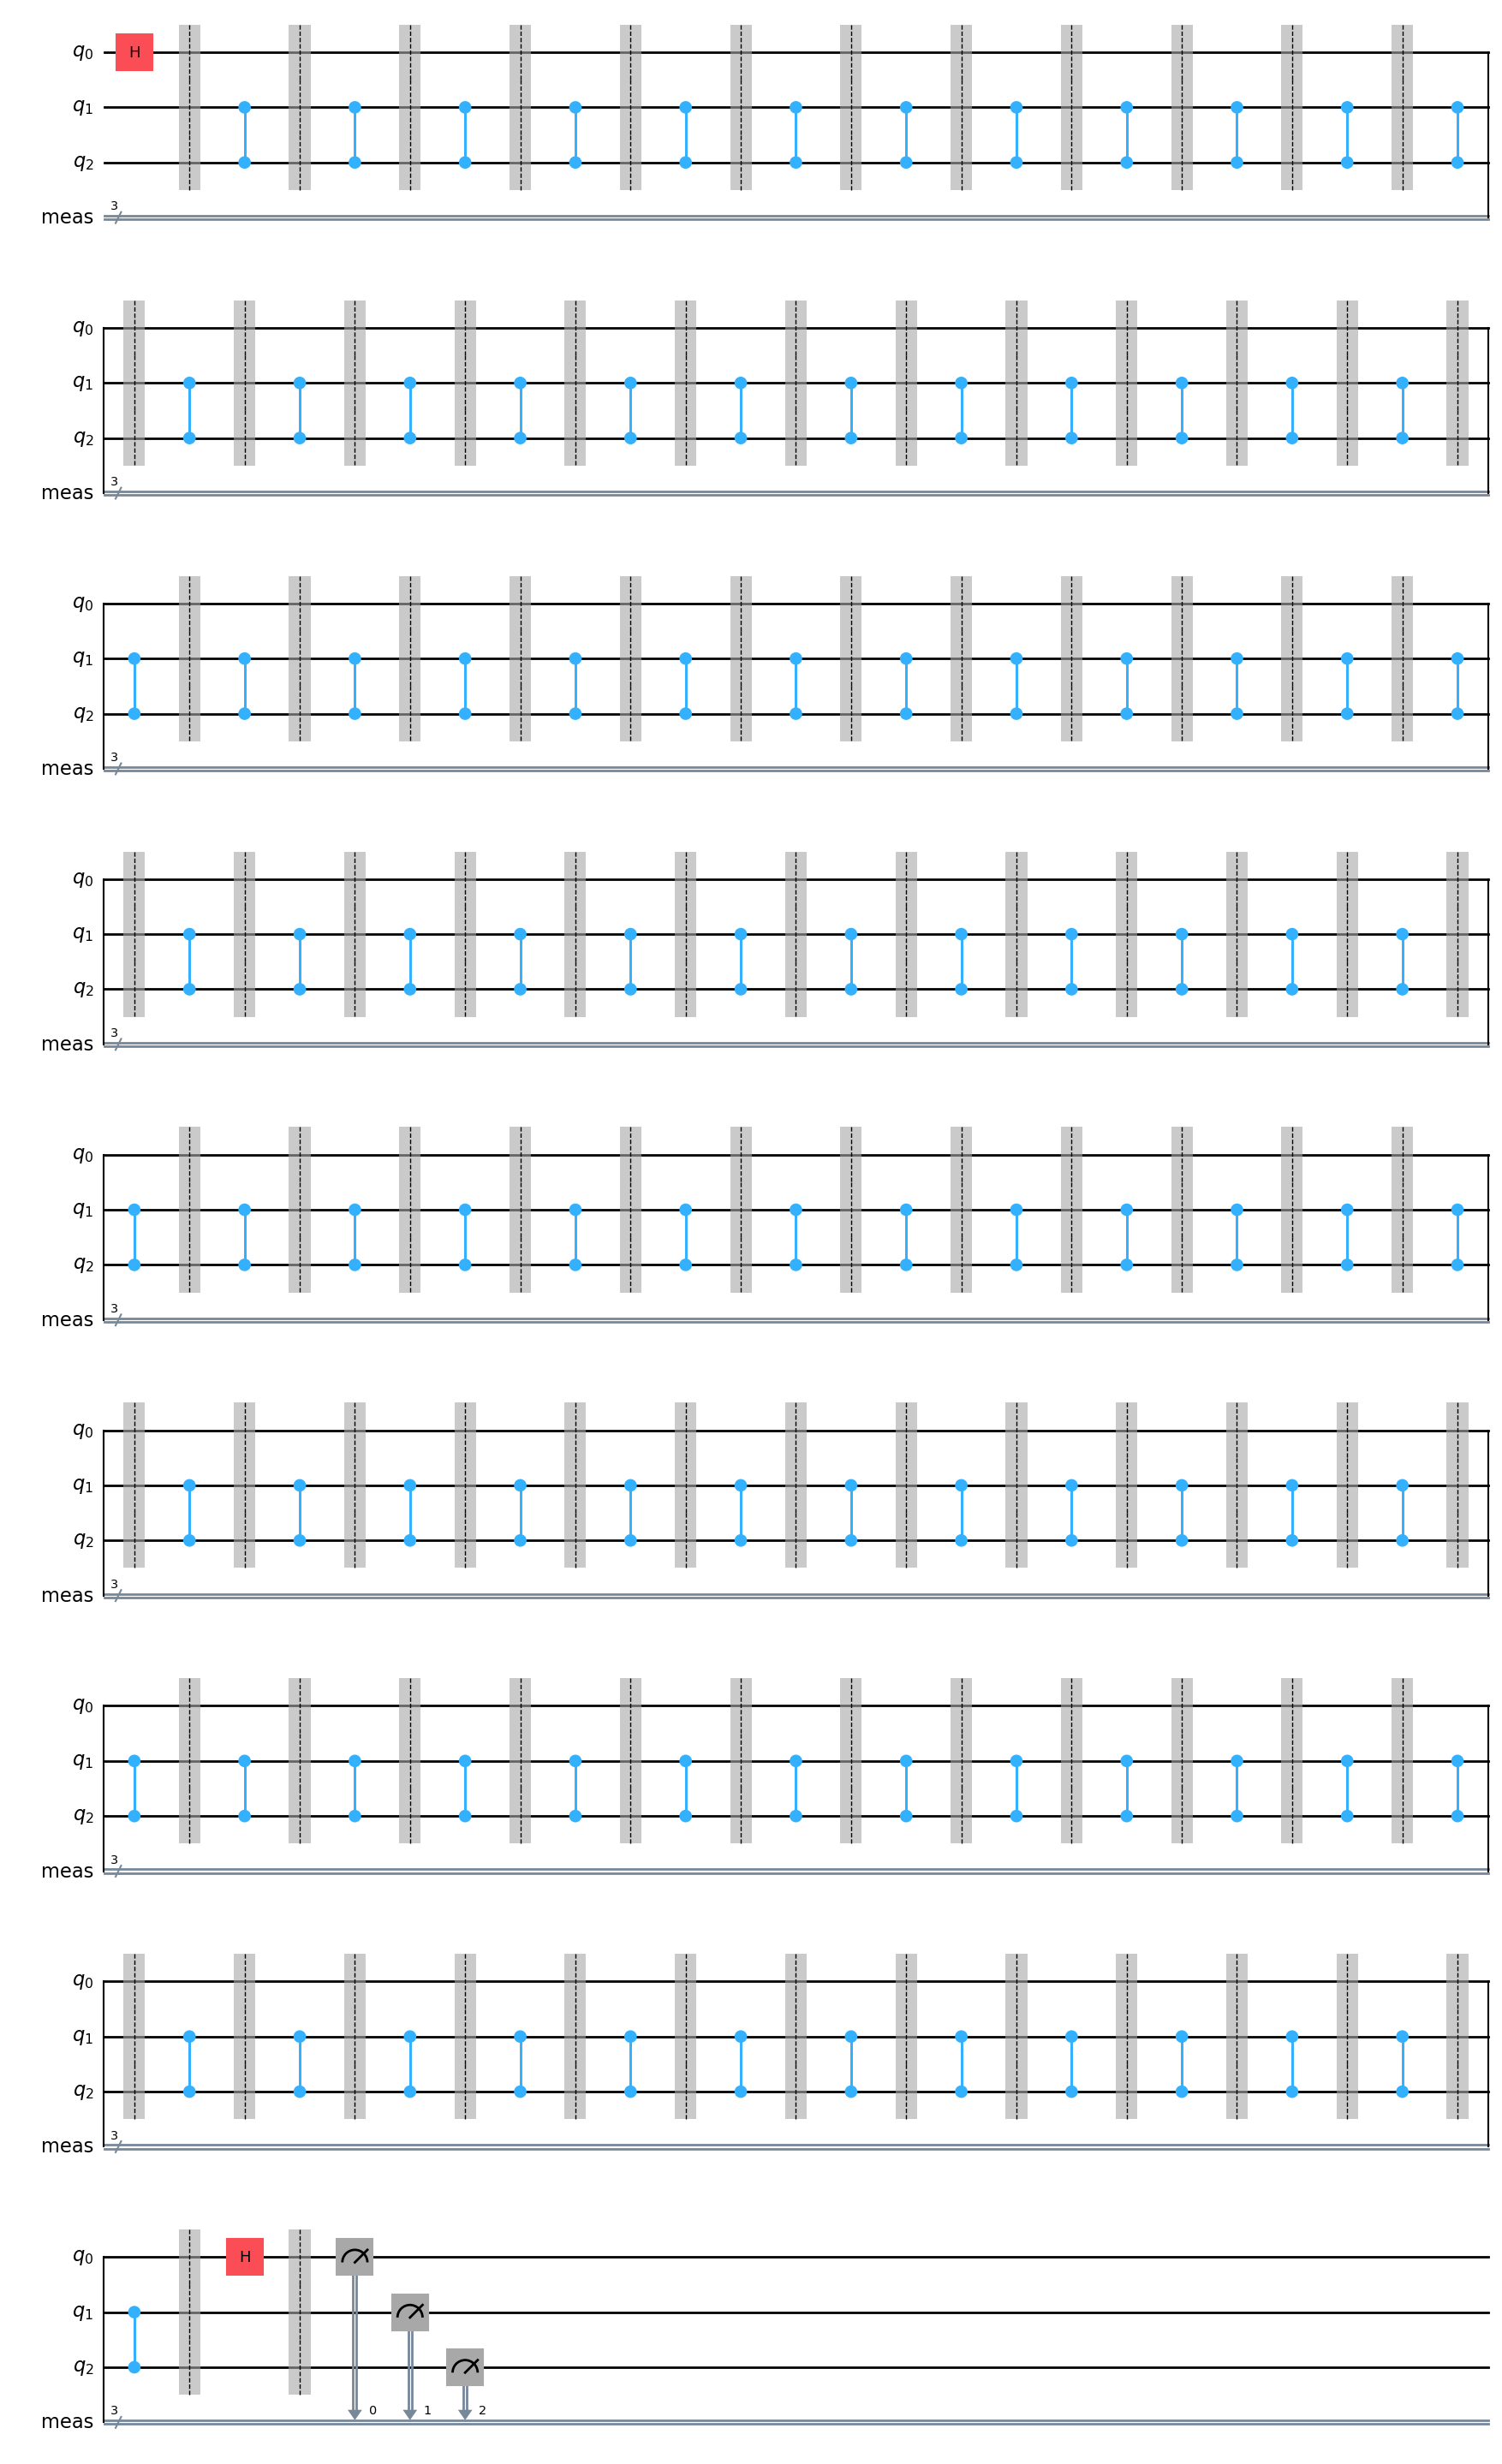

In [3]:
qc = QuantumCircuit(3)
for _ in range(1):
    qc.h(0)
    qc.barrier()
for _ in range(100):
    qc.cz(1, 2)
    qc.barrier()
qc.h(0)
qc.measure_all()
qc.draw(output='mpl')

In [4]:
qc_transpiled = transpile(qc, backend=backend, optimization_level=1)
circuits, compiler = qiskit_to_pulla(p, backend, qc_transpiled)

Now let us create a pair of Compiler settings objects, one with DD turned on and one without.

In [5]:
standard_compiler = p.get_standard_compiler()
standard_settings = standard_compiler.get_settings(circuits=circuits)
dd_settings = standard_compiler.get_settings(circuits=circuits)

There are two ways to define a DD sequence. First, by changing the attributes of the `dynamical_decoupling` compilation stage. Let's look at the available settings.

In [6]:
standard_settings.stages.dynamical_decoupling.apply_dd_strategy

", collection_type=, element_indices=None), value=True, read_only=False, path='stages.dynamical_decoupling.apply_dd_strategy.dd_is_disabled')"">dd_is_disabled",True,,dd_is_disabled
", collection_type=, element_indices=None), value=True, read_only=False, path='stages.dynamical_decoupling.apply_dd_strategy.use_standard_dd_strategy')"">use_standard_dd_strategy",True,,use_standard_dd_strategy
", collection_type=, element_indices=None), value=True, read_only=False, path='stages.dynamical_decoupling.apply_dd_strategy.DDStrategy_merge_contiguous_waits')"">DDStrategy_merge_contiguous_waits",True,,DDStrategy_merge_contiguous_waits
", collection_type=, element_indices=None), value=None, read_only=False, path='stages.dynamical_decoupling.apply_dd_strategy.DDStrategy_target_qubits')"">DDStrategy_target_qubits",not set/auto,,DDStrategy_target_qubits
", collection_type=, element_indices=None), value=True, read_only=False, path='stages.dynamical_decoupling.apply_dd_strategy.DDStrategy_skip_leading_wait')"">DDStrategy_skip_leading_wait",True,,DDStrategy_skip_leading_wait
", collection_type=, element_indices=None), value=True, read_only=False, path='stages.dynamical_decoupling.apply_dd_strategy.DDStrategy_skip_trailing_wait')"">DDStrategy_skip_trailing_wait",True,,DDStrategy_skip_trailing_wait
", collection_type=, element_indices=None), value=None, read_only=False, path='stages.dynamical_decoupling.apply_dd_strategy.DDStrategy_gate_sequences_ratio')"">DDStrategy_gate_sequences_ratio",not set/auto,,DDStrategy_gate_sequences_ratio
", collection_type=, element_indices=None), value=None, read_only=False, path='stages.dynamical_decoupling.apply_dd_strategy.DDStrategy_gate_sequences_gate_pattern_xy')"">DDStrategy_gate_sequences_gate_pattern_xy",not set/auto,,DDStrategy_gate_sequences_gate_pattern_xy
", collection_type=, element_indices=None), value=None, read_only=False, path='stages.dynamical_decoupling.apply_dd_strategy.DDStrategy_gate_sequences_align')"">DDStrategy_gate_sequences_align",not set/auto,,DDStrategy_gate_sequences_align


In [7]:
dd_settings.stages.dynamical_decoupling.apply_dd_strategy.dd_is_disabled = False
dd_settings.stages.dynamical_decoupling.apply_dd_strategy.DDStrategy_gate_sequences_ratio = [9, 5, 2]
dd_settings.stages.dynamical_decoupling.apply_dd_strategy.DDDStrategy_gate_sequences_gate_pattern_xy = [
"XYXYYXYX",
"YXYX",
"XX",
]
dd_settings.stages.dynamical_decoupling.apply_dd_strategy.DDStrategy_gate_sequences_align = ["asap", "asap", "center"]

dd_settings.stages.timebox_stage.prepend_heralding.add_heralding = False
dd_settings.stages.timebox_stage.prepend_reset.active_reset_cycles = None
dd_settings.stages.circuit_stage.subscribe_and_probe.convert_terminal_measurements = True
dd_settings.stages.circuit_stage.subscribe_and_probe.probe_all = True
dd_settings.stages.circuit_stage.validate_circuits.move_gate_validation = True
dd_settings.stages.schedule_stage.apply_move_gate_phase_corrections.move_gate_frame_tracking_mode = MoveGateFrameTrackingMode.FULL

Compiling the circuit using the non-DD compiler produces a schedule with a long wait on QB1__drive.awg.

In [8]:
shots = 1000
standard_settings.set_shots(shots)
standard_job_definition, standard_context = standard_compiler.compile(circuits=circuits, settings=standard_settings)
standard_playlist = standard_job_definition.sweep_definition.playlist

HTML(inspect_playlist(standard_playlist, [0]))

/home/ville/iqm/repot/continuous-delivery/.dev/environment/venv/lib/python3.11/site-packages/IPython/core/display.py:431: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


We then execute this schedule and compute the probability of finding QB1 in the |0> state. Ideally this should be one, but due to the decoherence experienced by the superposition state it will be less.

In [9]:
standard_job = p.submit_playlist(standard_job_definition, context=standard_context)
standard_job.wait_for_completion()
qiskit_result = sweep_job_to_qiskit(standard_job, shots=shots)

counts_orig = qiskit_result.get_counts()
print(f"\nQiskit result counts:\n{counts_orig}\n")

prob = marginal_distribution(counts_orig, indices=[0])['0'] / shots
print(f"Probability of finding qubit 0 it the |0> state (original circuit): {prob}")

[06-08 19:16:06;I] Waiting for job 019ea805-1808-75f3-851b-48c91b0dd11a to finish...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]


Qiskit result counts:
{'000': 506, '001': 443, '101': 6, '011': 14, '010': 21, '100': 9, '110': 1}

Probability of finding qubit 0 it the |0> state (original circuit): 0.537


Compiling the circuit using the DD compiler instead produces a schedule where the long wait on QB1__drive.awg is replaced by a DD sequence.

In [10]:
dd_settings.set_shots(shots)
dd_job_definition, dd_context = standard_compiler.compile(circuits=circuits, settings=dd_settings)
dd_playlist = dd_job_definition.sweep_definition.playlist

We execute the DD schedule and again compute the probability of finding QB1 in the |0> state, and will likely see that the probability has gone up, due to the DD sequence partially decoupling the idling QB1 from various decoherence sources and better preserving the superposition state.

In [11]:
dd_job = p.submit_playlist(dd_job_definition, context=dd_context)
dd_job.wait_for_completion()
qiskit_result = sweep_job_to_qiskit(dd_job, shots=shots)
counts_dd = qiskit_result.get_counts()
print(f"\nQiskit result counts:\n{counts_dd}\n")

prob = marginal_distribution(counts_dd, indices=[0])['0'] / shots
print(f"Probability of finding qubit 0 it the |0> state (dynamically decoupled circuit): {prob}")

[06-08 19:16:09;I] Waiting for job 019ea805-2330-7b03-ab75-51c0de3b2283 to finish...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]


Qiskit result counts:
{'000': 700, '001': 231, '010': 38, '101': 5, '100': 13, '011': 12, '110': 1}

Probability of finding qubit 0 it the |0> state (dynamically decoupled circuit): 0.752


We can see that the long wait on QB1__drive.awg was indeed replaced by a DD sequence.

In [12]:
HTML(inspect_playlist(dd_playlist, [0]))

You can also define the DD strategy as part of the compilation context.

In [13]:
# First, you construct the DDStrategy object
from iqm.station_control.interface.models import DDStrategy

dd_strategy = DDStrategy(
    gate_sequences=[(9, "XYXYYXYX", "asap"), (5, "YXYX", "asap"), (2, "XX", "center")],
    target_qubits=["QB1"],
    )
dd_settings.stages.dynamical_decoupling.apply_dd_strategy.dd_is_disabled = False

In [14]:
dd_job_definition, dd_context = standard_compiler.compile(
    circuits=circuits, 
    settings=dd_settings,
    context={"dd_strategy": dd_strategy}
)
dd_playlist = dd_job_definition.sweep_definition.playlist

In [15]:
dd_job = p.submit_playlist(dd_job_definition, context=dd_context)
dd_job.wait_for_completion()
qiskit_result = sweep_job_to_qiskit(dd_job, shots=shots)
counts_dd = qiskit_result.get_counts()
print(f"\nQiskit result counts:\n{counts_dd}\n")

prob = marginal_distribution(counts_dd, indices=[0])['0'] / shots
print(f"Probability of finding qubit 0 it the |0> state (dynamically decoupled circuit): {prob}")

[06-08 19:16:12;I] Waiting for job 019ea805-2f2a-7ea1-b408-9c63bea4b41c to finish...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]


Qiskit result counts:
{'000': 742, '001': 209, '100': 6, '010': 29, '101': 8, '011': 4, '111': 1, '110': 1}

Probability of finding qubit 0 it the |0> state (dynamically decoupled circuit): 0.778


In [16]:
HTML(inspect_playlist(dd_playlist, [0]))